In [1]:
import pandas as pd

In [2]:
df = pd.DataFrame({
    'temperature': [10, 7, 4, 0],
    'sales': [30, 50, 60, 80]
})

display(df)

,temperature,sales
0,10,30
1,7,50
2,4,60
3,0,80


In [3]:
import torch

x_tensor = torch.tensor(df['temperature'].values, dtype=torch.float32) # 텐서로 바꿔줄 때 줄 번호 없이 값만 보고 싶으면 values()

x_tensor

tensor([10.,  7.,  4.,  0.])

In [4]:
y_tensor = torch.tensor(df['sales'].values, dtype=torch.float32)

y_tensor

tensor([30., 50., 60., 80.])

In [5]:
a = torch.tensor(-4.0, requires_grad=True)

a

tensor(-4., requires_grad=True)

In [6]:
b = torch.tensor(80.0, requires_grad=True)

b

tensor(80., requires_grad=True)

In [14]:
learning_rate = 0.001
epochs = 1000
cost_history = []

In [15]:
initial_a = a.item() # 불필요한 정보 다 빼고 값만 확인할 때 .item()

initial_a

-4.0

In [16]:
initial_b = b.item()

initial_b

80.0

In [34]:
with torch.no_grad():
    error = y_tensor - (x_tensor*a + b)
    print(f'error={error}')
    
    initial_cost = torch.mean(error ** 2).item()
    print(f'initial_cost={initial_cost}')
print(f'학습 전 a={initial_a:.4f}, b={initial_b:.4f}, Cost={initial_cost:.4f}')

error=tensor([-2.0843,  3.4974, -0.9209, -0.1454])
initial_cost=4.361304759979248
학습 전 a=-4.0000, b=80.0000, Cost=4.3613


In [ ]:
for epoch in range(epochs):
    
    # 현재 a,b로 계산한 예측값
    pred = a * x_tensor + b

    # 실제값 - 예측값    
    error = y_tensor - pred
    
    # 현재 예측이 실제값과 얼마나 차이나는지 나타냄
    cost = torch.mean(error ** 2)
    cost.backward()
    
    with torch.no_grad():
        a -= learning_rate * a.grad # a.grad: pyTorch가 계산한 a의 gradient
        b -= learning_rate * b.grad # b.grad: pyTorch가 계산한 b의 gradient
        
    # pyTorch는 gradient를 자동으로 누적 -> 매 epoch마다 초기화 필요
    a.grad.zero_()
    b.grad.zero_()
    
    cost_history.append(cost.item())
    
    if epoch % 100 == 0:
        print(f'epoch={epoch}, Cost={cost.item():.4f}, a={a.item():.4f}, b={b.item():.4f}')

epoch=0, Cost=30.0000, a=-4.0650, b=79.9920
epoch=100, Cost=4.4137, a=-4.7788, b=79.9333
epoch=200, Cost=4.4044, a=-4.7828, b=79.9635
epoch=300, Cost=4.3963, a=-4.7864, b=79.9917
epoch=400, Cost=4.3891, a=-4.7898, b=80.0183
epoch=500, Cost=4.3829, a=-4.7930, b=80.0431
epoch=600, Cost=4.3774, a=-4.7960, b=80.0664
epoch=700, Cost=4.3725, a=-4.7988, b=80.0881
epoch=800, Cost=4.3683, a=-4.8014, b=80.1085
epoch=900, Cost=4.3646, a=-4.8038, b=80.1276


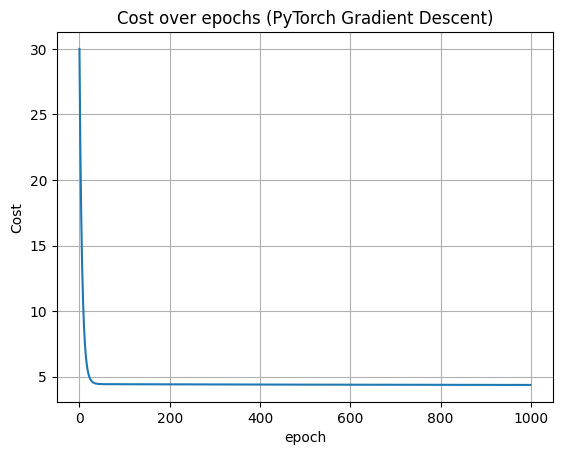

In [19]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(range(len(cost_history)), cost_history)
plt.title('Cost over epochs (PyTorch Gradient Descent)')
plt.xlabel('epoch')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

In [36]:
# 학습 반복문이 끝난 뒤 남아있는 a, b -> 학습된 값
final_a = a.item()
final_b = b.item()

with torch.no_grad():
    final_cost = (torch.mean((y_tensor - (a*x_tensor + b)) ** 2)).item()

print('학습 전')
print(f'a = {initial_a:.4f}')
print(f'b = {initial_b:.4f}')
print(f'Cost = {initial_cost:.4f}')

print('\n학습 후')
print(f'a = {final_a:.4f}')
print(f'b = {final_b:.4f}')
print(f'Cost = {final_cost:.4f}')

학습 전
a = -4.0000
b = 80.0000
Cost = 4.3613

학습 후
a = -4.8061
b = 80.1454
Cost = 4.3613


In [37]:
final_a = a.item()
final_b = b.item()

new_x = 5
predicted_y = final_a * new_x + final_b

print(f'학습된 식: y = {final_a:.2f}X + {final_b:.2f}')
print(f'기온이 {new_x}도일 때 예상 판매량: {predicted_y:.2f}개')

학습된 식: y = -4.81X + 80.15
기온이 5도일 때 예상 판매량: 56.11개


In [ ]:
def run_gradient_descent(learning_rate, epochs):
    
    # run_gradient_descent 함수
    # 입력값: 
    #   learning_rate: 한 번에 얼마나 크게 수정할지 정하는 값 (보폭)
    #   epochs       : 전체 학습을 몇 번 반복할지 정하는 값
    # 반환값:
    #   최종 a, 최종 b, 최종 Cost
    # 12번의 pyTorch 학습 코드를 learning_rate를 바꿔 실험할 수 있게 함수로 묶은 것
    
    # 항상 같은 출발선(Y = -4X + 80)에서 시작
    a = torch.tensor(-4.0, requires_grad=True)
    b = torch.tensor(80.0, requires_grad=True)
    
    print(f'learning_rate={learning_rate}')
    
    for epoch in range(epochs):
        pred = a * x_tensor + b
        error = y_tensor - pred       # error = 실제값 - 예측값
        cost = torch.mean(error ** 2) # Cost = 오차 제곱 평균
        
        cost.backward()               # gradient 자동 계산
        
        with torch.no_grad():
            a -= learning_rate * a.grad
            b -= learning_rate * b.grad
            
        # 다음 반복을 위해 gradient 초기화
        a.grad.zero_()
        b.grad.zero_()
        
        # 안전장치: Cost가 너무 커지면(발산) 더 돌려봐야 의미가 없으므로 즉시 중단
        if (epoch+1) % 100 == 0:
            print(f'cost={cost}, a={a}, b={b}')
        
        if cost.item() > 1000000:
            print('Cost가 너무 커져 학습이 불안정해졌습니다. Learning Rate가 너무 클 수 있습니다.')
            print(f'cost={cost}, a={a}, b={b}, epoch={epoch}')
            return a.item(), b.item(), cost.item()
    
    return a.item(), b.item(), cost.item() # 무사히 끝나면 최종 a, b, Cost 반환

In [39]:
learning_rates = [0.1, 0.01, 0.001, 0.0001]

for lr in learning_rates:
    final_a, final_b, final_cost = run_gradient_descent(lr, 1000)
    print(f'learning_rate={lr}, 최종 Cost={final_cost:.4f}')
    print('-' * 40)

learning_rate=0.1
Cost가 너무 커져 학습이 불안정해졌습니다. Learning Rate가 너무 클 수 있습니다.
cost=4147874.0, a=2299.154541015625, b=375.590087890625, epoch=3
learning_rate=0.1, 최종 Cost=4147874.0000
----------------------------------------
learning_rate=0.01
cost=4.361520767211914, a=-4.806181907653809, b=80.14591979980469
cost=4.344273567199707, a=-4.8225202560424805, b=80.27328491210938
cost=4.339619159698486, a=-4.831007957458496, b=80.33944702148438
cost=4.338364124298096, a=-4.835416793823242, b=80.37380981445312
cost=4.338021278381348, a=-4.837707042694092, b=80.39166259765625
cost=4.337930202484131, a=-4.838896751403809, b=80.40093994140625
cost=4.3379058837890625, a=-4.839515209197998, b=80.40575408935547
cost=4.337898254394531, a=-4.8398332595825195, b=80.40823364257812
cost=4.337903022766113, a=-4.839993953704834, b=80.40948486328125
cost=4.337903022766113, a=-4.840090751647949, b=80.41024780273438
learning_rate=0.01, 최종 Cost=4.3379
----------------------------------------
learning_rate=0.001
cost

In [32]:
run_gradient_descent(0.000001, 1000)

learning_rate=1e-06
cost=29.57923698425293, a=-4.006471633911133, b=79.99923706054688
cost=29.161123275756836, a=-4.012890338897705, b=79.99847412109375
cost=28.749895095825195, a=-4.019256114959717, b=79.99771118164062
cost=28.34542465209961, a=-4.025568962097168, b=79.9969482421875
cost=27.947582244873047, a=-4.031829833984375, b=79.99618530273438
cost=27.556276321411133, a=-4.038038730621338, b=79.99542236328125
cost=27.17144203186035, a=-4.044196128845215, b=79.99465942382812
cost=26.792978286743164, a=-4.0503010749816895, b=79.993896484375
cost=26.420894622802734, a=-4.0563530921936035, b=79.99313354492188
cost=26.054941177368164, a=-4.062355041503906, b=79.99237060546875


(-4.062355041503906, 79.99237060546875, 26.054941177368164)

In [33]:
run_gradient_descent(0.001, 1000)

learning_rate=0.001
cost=4.413830757141113, a=-4.778733253479004, b=79.93294525146484
cost=4.404530048370361, a=-4.7827372550964355, b=79.96316528320312
cost=4.396376609802246, a=-4.786367416381836, b=79.99146270751953
cost=4.389216423034668, a=-4.789767742156982, b=80.01799774169922
cost=4.382925987243652, a=-4.79295539855957, b=80.04286193847656
cost=4.377412796020508, a=-4.795940399169922, b=80.06613159179688
cost=4.372576713562012, a=-4.798735618591309, b=80.0879135131836
cost=4.36833381652832, a=-4.801354885101318, b=80.10830688476562
cost=4.364605903625488, a=-4.803813934326172, b=80.12744903564453
cost=4.361336708068848, a=-4.806109428405762, b=80.14537048339844


(-4.806109428405762, 80.14537048339844, 4.361336708068848)